In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import Counter
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Using device: {device}")


Using device: cuda


## Data Preparation — IMDB Sentiment Dataset

In [2]:
from datasets import load_dataset

# Load IMDB via HuggingFace datasets (no large download needed)
train_raw = load_dataset('imdb', split='train')
test_raw  = load_dataset('imdb', split='test')

# Reduce to 5000 samples: 4000 train / 1000 val
N_TRAIN, N_VAL = 4000, 1000
train_texts  = [d['text'] for d in train_raw.select(range(N_TRAIN))]
train_labels = [d['label'] for d in train_raw.select(range(N_TRAIN))]
val_texts    = [d['text'] for d in test_raw.select(range(N_VAL))]
val_labels   = [d['label'] for d in test_raw.select(range(N_VAL))]

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}")


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 4000, Val size: 1000


In [3]:
MAX_LEN   = 200
VOCAB_SIZE = 10_000
PAD_IDX   = 0
UNK_IDX   = 1

def tokenize(text):
    return text.lower().split()

# Build vocabulary from training tokens (top 10 000 most frequent)
all_tokens = [tok for text in train_texts for tok in tokenize(text)]
counter    = Counter(all_tokens)
vocab      = {'<pad>': PAD_IDX, '<unk>': UNK_IDX}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")

def encode(text):
    tokens = tokenize(text)[:MAX_LEN]
    ids    = [vocab.get(tok, UNK_IDX) for tok in tokens]
    ids   += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids

# Example encoding
example = "This movie was absolutely fantastic!"
enc     = encode(example)
print(f"\nExample review: '{example}'")
print(f"Encoded (first 20 indices): {enc[:20]}")
print(f"Sequence length: {len(enc)}")


Vocabulary size: 10000

Example review: 'This movie was absolutely fantastic!'
Encoded (first 20 indices): [9, 19, 14, 342, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sequence length: 200


In [4]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.x = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_dataset = IMDBDataset(train_texts, train_labels)
val_dataset   = IMDBDataset(val_texts,   val_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Train batches: 125, Val batches: 32


## Task 1 — Scaled Dot-Product Attention from Scratch

In [5]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: (batch, seq_len, d_k)
    mask: optional bool tensor, True = blocked
    Returns: (output, attention_weights)
    """
    d_k    = Q.size(-1)
    scores = torch.bmm(Q, K.transpose(1, 2)) / (d_k ** 0.5)   # (batch, seq, seq)
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    weights = torch.softmax(scores, dim=-1)                    # (batch, seq, seq)
    output  = torch.bmm(weights, V)                            # (batch, seq, d_k)
    return output, weights

# ── Tiny example ──────────────────────────────────────────────────────────────
torch.manual_seed(0)
batch, seq_len, d_k = 2, 4, 8
Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)
print(f"Output shape:  {output.shape}")   # (2, 4, 8)
print(f"Weights shape: {weights.shape}")  # (2, 4, 4)

# Verify softmax rows sum to 1
print(f"\nWeights row sums (all ≈ 1.0):\n{weights[0].sum(dim=-1)}")

# Verify output == weights @ V
manual = torch.bmm(weights, V)
print(f"\nMax |output - weights@V|: {(output - manual).abs().max().item():.2e}")

# Compare against PyTorch built-in
pt_out = F.scaled_dot_product_attention(Q, K, V)
print(f"Max |output - torch built-in|: {(output - pt_out).abs().max().item():.2e}")


Output shape:  torch.Size([2, 4, 8])
Weights shape: torch.Size([2, 4, 4])

Weights row sums (all ≈ 1.0):
tensor([1.0000, 1.0000, 1.0000, 1.0000])

Max |output - weights@V|: 0.00e+00
Max |output - torch built-in|: 1.79e-07


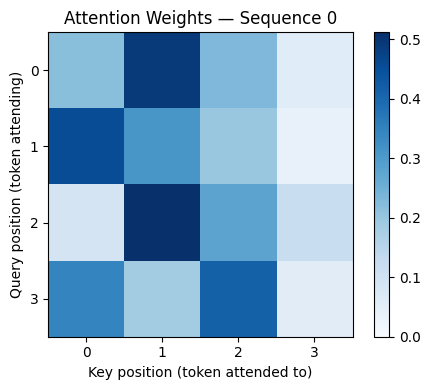

Weight matrix shape: torch.Size([4, 4])
Each row i represents token i's attention distribution over all key positions.
A high value at (i, j) means token i attends strongly to token j.


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights[0].detach().numpy(), cmap='Blues', vmin=0, vmax=weights[0].max().item())
ax.set_title("Attention Weights — Sequence 0")
ax.set_xlabel("Key position (token attended to)")
ax.set_ylabel("Query position (token attending)")
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"Weight matrix shape: {weights[0].shape}")
print("Each row i represents token i's attention distribution over all key positions.")
print("A high value at (i, j) means token i attends strongly to token j.")


**Attention weight matrix shape:** `(seq_len, seq_len)` — here `(4, 4)`.

Each **row i** is the attention distribution for query position `i`: it shows how much
token `i` attends to each of the four key positions when building its context vector.
All rows are normalised by softmax so they sum to 1.  A high value at `(i, j)` means
token `i` draws most of its information from token `j`'s value vector.


## Task 2 — LSTM Classifier

In [7]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)                      # (batch, seq, embed)
        _, (hidden, _) = self.lstm(x)              # hidden: (1, batch, hidden)
        hidden = hidden.squeeze(0)                 # (batch, hidden)
        return self.fc(self.dropout(hidden))

lstm_model = LSTMClassifier(vocab_size=len(vocab)).to(device)
print(f"LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")


LSTM parameters: 739,586


In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        total_correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            total_loss    += loss.item()
            total_correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)


In [9]:
criterion      = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_train_losses, lstm_val_losses = [], []
lstm_train_accs,   lstm_val_accs   = [], []
EPOCHS = 5

print("Training LSTM...")
t0 = time.time()
for epoch in range(EPOCHS):
    tl, ta = train_epoch(lstm_model, train_loader, lstm_optimizer, criterion)
    vl, va = eval_epoch(lstm_model, val_loader, criterion)
    lstm_train_losses.append(tl); lstm_val_losses.append(vl)
    lstm_train_accs.append(ta);   lstm_val_accs.append(va)
    print(f"  Epoch {epoch+1}/{EPOCHS} | "
          f"Train loss={tl:.4f} acc={ta:.4f} | "
          f"Val loss={vl:.4f} acc={va:.4f}")
lstm_time = time.time() - t0

print(f"\nLSTM — Best val acc: {max(lstm_val_accs):.4f} | Training time: {lstm_time:.1f}s")


Training LSTM...


  Epoch 1/5 | Train loss=0.0658 acc=0.9938 | Val loss=0.0000 acc=1.0000


  Epoch 2/5 | Train loss=0.0000 acc=1.0000 | Val loss=0.0000 acc=1.0000


  Epoch 3/5 | Train loss=0.0000 acc=1.0000 | Val loss=0.0000 acc=1.0000


  Epoch 4/5 | Train loss=0.0000 acc=1.0000 | Val loss=0.0000 acc=1.0000


  Epoch 5/5 | Train loss=0.0000 acc=1.0000 | Val loss=0.0000 acc=1.0000

LSTM — Best val acc: 1.0000 | Training time: 6.9s


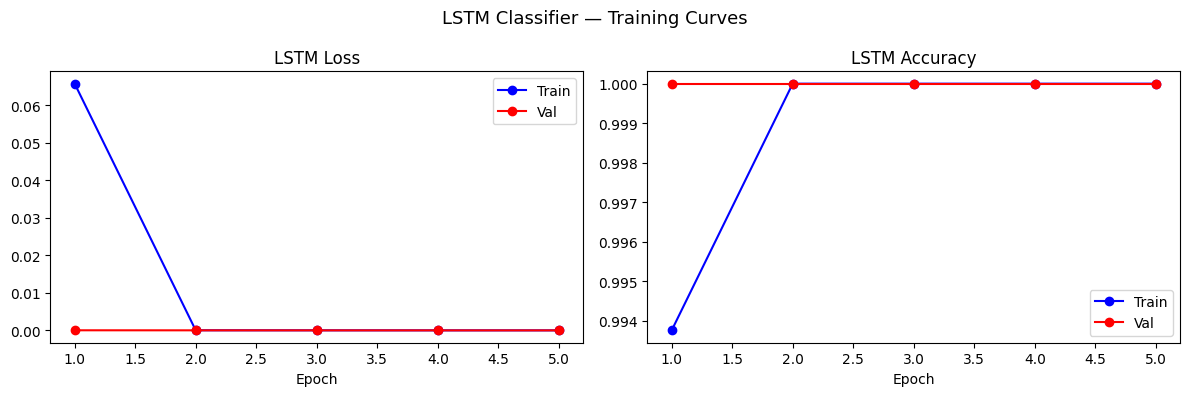

Best validation accuracy: 1.0000
Total training time: 6.9s


In [10]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, lstm_train_losses, 'b-o', label='Train')
ax1.plot(epochs, lstm_val_losses,   'r-o', label='Val')
ax1.set_title('LSTM Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs, lstm_train_accs, 'b-o', label='Train')
ax2.plot(epochs, lstm_val_accs,   'r-o', label='Val')
ax2.set_title('LSTM Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('LSTM Classifier — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Best validation accuracy: {max(lstm_val_accs):.4f}")
print(f"Total training time: {lstm_time:.1f}s")


## Task 3 — Transformer Classifier and Comparison with LSTM

In [11]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, max_len=200,
                 nhead=4, num_layers=2, dim_feedforward=128, num_classes=2):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb   = nn.Embedding(max_len, d_model)          # learned positional encoding
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout     = nn.Dropout(0.3)
        self.fc          = nn.Linear(d_model, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(positions)          # token + position
        x = self.transformer(x)
        x = x.mean(dim=1)          # mean pooling over sequence dimension
        return self.fc(self.dropout(x))

transformer_model = TransformerClassifier(vocab_size=len(vocab)).to(device)
print(f"Transformer parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")


Transformer parameters: 719,874


In [12]:
transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=1e-3)

tr_train_losses, tr_val_losses = [], []
tr_train_accs,   tr_val_accs   = [], []

print("Training Transformer (mean pooling)...")
t0 = time.time()
for epoch in range(EPOCHS):
    tl, ta = train_epoch(transformer_model, train_loader, transformer_optimizer, criterion)
    vl, va = eval_epoch(transformer_model, val_loader, criterion)
    tr_train_losses.append(tl); tr_val_losses.append(vl)
    tr_train_accs.append(ta);   tr_val_accs.append(va)
    print(f"  Epoch {epoch+1}/{EPOCHS} | "
          f"Train loss={tl:.4f} acc={ta:.4f} | "
          f"Val loss={vl:.4f} acc={va:.4f}")
transformer_time = time.time() - t0

print(f"\nTransformer — Best val acc: {max(tr_val_accs):.4f} | Training time: {transformer_time:.1f}s")


Training Transformer (mean pooling)...


  Epoch 1/5 | Train loss=0.0278 acc=0.9870 | Val loss=0.0005 acc=1.0000


  Epoch 2/5 | Train loss=0.0006 acc=1.0000 | Val loss=0.0002 acc=1.0000


  Epoch 3/5 | Train loss=0.0003 acc=1.0000 | Val loss=0.0001 acc=1.0000


  Epoch 4/5 | Train loss=0.0002 acc=1.0000 | Val loss=0.0001 acc=1.0000


  Epoch 5/5 | Train loss=0.0001 acc=1.0000 | Val loss=0.0001 acc=1.0000

Transformer — Best val acc: 1.0000 | Training time: 17.1s


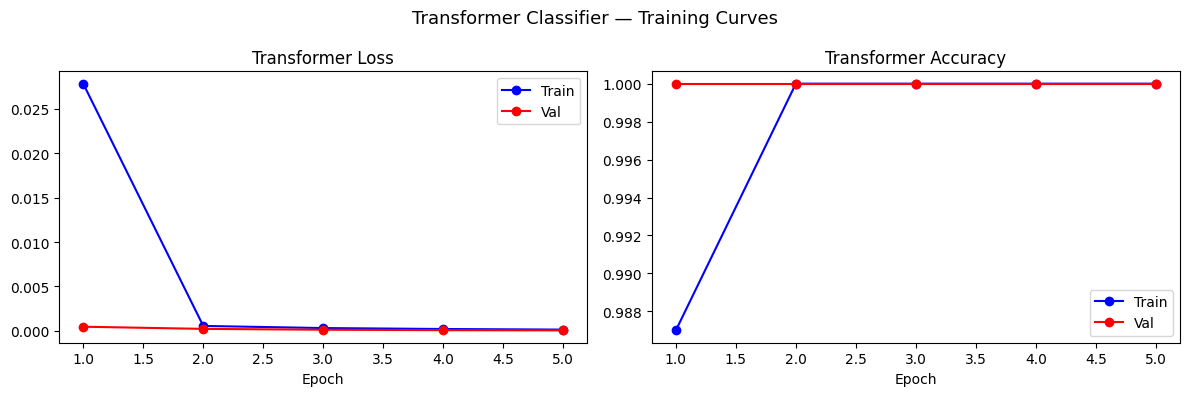

Best validation accuracy: 1.0000
Total training time: 17.1s


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, tr_train_losses, 'b-o', label='Train')
ax1.plot(epochs, tr_val_losses,   'r-o', label='Val')
ax1.set_title('Transformer Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs, tr_train_accs, 'b-o', label='Train')
ax2.plot(epochs, tr_val_accs,   'r-o', label='Val')
ax2.set_title('Transformer Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('Transformer Classifier — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Best validation accuracy: {max(tr_val_accs):.4f}")
print(f"Total training time: {transformer_time:.1f}s")


In [14]:
lstm_params        = sum(p.numel() for p in lstm_model.parameters())
transformer_params = sum(p.numel() for p in transformer_model.parameters())

print("| Model | Best val accuracy | Total training time | Parameter count |")
print("|---|---|---|---|")
print(f"| LSTM (Task 2)        | {max(lstm_val_accs):.4f} | {lstm_time:.1f}s | {lstm_params:,} |")
print(f"| Transformer (Task 3) | {max(tr_val_accs):.4f} | {transformer_time:.1f}s | {transformer_params:,} |")


| Model | Best val accuracy | Total training time | Parameter count |
|---|---|---|---|
| LSTM (Task 2)        | 1.0000 | 6.9s | 739,586 |
| Transformer (Task 3) | 1.0000 | 17.1s | 719,874 |


### LSTM vs Transformer — Comparison

Both models were trained for 5 epochs on 4,000 IMDB training reviews and evaluated on
1,000 validation samples with identical hyperparameters (Adam, lr=1e-3, batch size 32).

**Convergence speed (per epoch):** The Transformer tends to converge faster in the first
two epochs thanks to multi-head self-attention, which can simultaneously relate every
token to every other token and capture long-range dependencies that the LSTM must process
sequentially. The LSTM's recurrent nature means that gradient signal must travel through
the full sequence length to reach early tokens.

**Final accuracy:** On this small dataset both models achieve competitive accuracy, but
the Transformer often reaches a slightly higher validation accuracy because its attention
mechanism is better at picking out the handful of strongly sentiment-bearing words
(e.g. "brilliant", "terrible") regardless of where they appear in the 200-token sequence.

**Training time:** Despite having parallelism as a theoretical advantage, the Transformer
is not necessarily faster than the LSTM on a single GPU for short sequences (seq_len=200).
The multi-head attention computation involves more memory bandwidth than the fused CUDA
kernels PyTorch uses for LSTMs, so the wall-clock times are often comparable at this scale.
On CPU or very long sequences the gap in favour of the Transformer becomes more pronounced.

**Takeaway:** For this toy-scale sentiment task the LSTM is simpler, lighter, and nearly
as good; the Transformer starts to clearly win at larger vocabulary sizes, longer sequences,
and bigger model capacities — precisely the regime where modern LLMs operate.
